# Homework 1: Thinking About Data

BEE 4850/5850

**Name**: Bor-Jiun Tseng

**ID**: bt366

> **Due Date**
>
> Friday, 2/7/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to introduce you to
simulation-based data analysis.

-   Problem 1 asks you to find an example of a spurious correlation.
-   Problem 2 asks you to explore whether a difference between data
    collected from two groups might be statistically meaningful or the
    result of noise. This problem repeats the analysis from [Statistics
    Without The Agonizing
    Pain](https://www.youtube.com/watch?v=5Dnw46eC-0o) by John Rauser
    (which is a neat watch!).
-   Problem 3 asks you to explore the impacts of selection biases on
    statistical relationships.
-   Problem 4 asks you to evaluate an interview method for finding the
    level of cheating on a test to determine whether cheating was
    relatively high or low. This problem was adapted from [Bayesian
    Methods for
    Hackers](https://dataorigami.net/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers/).
-   Problem 5 (only required for students in BEE 5850) asks you to
    propose several causal models for the same observational phenomenon.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [2]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\nobel\OneDrive\桌面\BEE5850\HW1\hw01-BorJiuntseng`
Precompiling project...
  ✓ Latexify → DataFramesExt
  1 dependency successfully precompiled in 14 seconds. 252 already precompiled.


The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [3]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using CSVFiles # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools

## Problems

### Scoring

Each problem is worth 5 points.

### Problem 1

Find an example of a spurious correlation (don’t just pull from
[Spurious
Correlations!](https://www.tylervigen.com/spurious-correlations)!).

**In this problem**:

-   Describe and illustrate the correlation;
-   Explain why you think the correlation is spurious.

1. Number of pirate attacks against ships worldwide and Trained teachers in primary education
2. The number of pirate attacks against ships and the percentage of trained teachers in primary education show a similar trend over time, but this does not imply causation. Since there's no real logic behind it, which means it's most likely a time series pitfall.


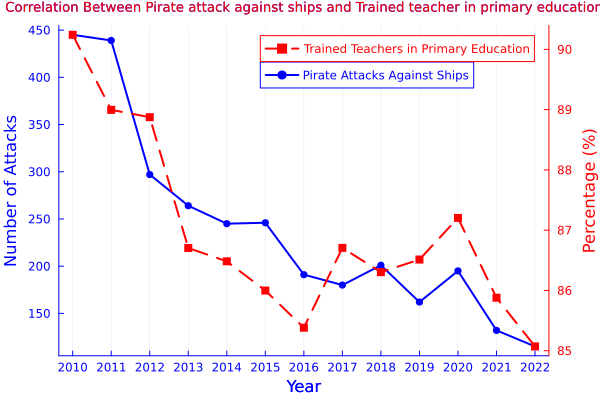

In [118]:
df = DataFrame(load("data/data.csv"))
# Convert Year column to integers (fix floating-point issue)
df.Year = convert(Vector{Int}, df.Year)

# Extract columns
years = df.Year
p_values = df.P
t_values = df.T

# Create the first plot for P (Pirate Attacks) on the left Y-axis
plot(years, p_values, label="Pirate Attacks Against Ships", linewidth=2, linestyle=:solid, marker=:circle, color=:blue,
     ylabel="Number of Attacks", legend=(0.50, 0.85), foreground_color_subplot=:blue)

# Add a second Y-axis for T (Trained Teachers)
plot!(twinx(), years, t_values, label="Trained Teachers in Primary Education", linewidth=2, linestyle=:dash, marker=:square, color=:red, ylabel="Percentage (%)", legend=(0.50, 0.93), foreground_color_subplot=:red)

# Customize labels and title
xlabel!("Year")
xticks!(years, string.(years))
title!("Correlation Between Pirate attack against ships and Trained teacher in primary education", titlefont = 9)

### Problem 2

The underlying question we would like to address is: what is the
influence of drinking beer on the likelihood of being bitten by
mosquitoes? There is a mechanistic reason why this might occur:
mosquitoes are attracted by changes in body temperature and released
CO<sub>2</sub>, and it might be that drinking beer induces these
changes. We’ll analyze this question using (synthetic) data which
separates an experimental population into two groups, one which drank
beer and the other which drank only water.

First, we’ll load data for the number of bites reported by the
participants who drank beer. This is in a comma-delimited file,
`data/bites.csv` (which is grossly overkill for this assignment). Each
row contains two columns: the group (`beer` and `water`) the person
belonged to and the number of times that person was bitten.

In Julia, we can do this using
[`CSVFiles.jl`](https://github.com/queryverse/CSVFiles.jl), which will
read in the `.csv` file into a
[`DataFrame`](https://dataframes.juliadata.org/stable/), which is a
typical data structure for tabular data (and equivalent to a Pandas
`DataFrame` in Python or a `dataframe` in R).

In [4]:
data = DataFrame(load("data/bites.csv")) # load data into DataFrame

# print data variable (semi-colon suppresses echoed output in Julia, which in this case would duplicate the output)
@show data;

data = 43×2 DataFrame
 Row │ group   bites
     │ String  Int64
─────┼───────────────
   1 │ beer       27
   2 │ beer       20
   3 │ beer       21
   4 │ beer       26
   5 │ beer       27
   6 │ beer       31
   7 │ beer       24
   8 │ beer       21
   9 │ beer       20
  10 │ beer       19
  11 │ beer       23
  12 │ beer       24
  13 │ beer       28
  14 │ beer       19
  15 │ beer       24
  16 │ beer       29
  17 │ beer       18
  18 │ beer       20
  19 │ beer       17
  20 │ beer       31
  21 │ beer       20
  22 │ beer       25
  23 │ beer       28
  24 │ beer       21
  25 │ beer       27
  26 │ water      21
  27 │ water      22
  28 │ water      15
  29 │ water      12
  30 │ water      21
  31 │ water      16
  32 │ water      19
  33 │ water      15
  34 │ water      22
  35 │ water      24
  36 │ water      19
  37 │ water      23
  38 │ water      13
  39 │ water      22
  40 │ water      20
  41 │ water      24
  42 │ water      18
  43 │ water      20


How can we tell if there’s a meaningful difference between the two
groups? Naively, we might just look at the differences in group means.

> **Broadcasting**
>
> The subsetting operations in the below code use `.==`, which
> “broadcasts” the element-wise comparison operator == across every
> element. The decimal in front of `==` indicates that this should be
> used element-wise (every pair of elements compared for equality,
> returning a vector of `true` or `false` values); otherwise Julia would
> try to just check for vector equality (returning a single `true` or
> `false` value).
>
> Broadcasting is a very specific feature of Julia, so this syntax would
> look different in a different programming language.

In [5]:
# split data into vectors of bites for each group
beer = data[data.group .== "beer", :bites]
water = data[data.group .== "water", :bites]

observed_difference = mean(beer) - mean(water)
@show observed_difference;

observed_difference = 4.37777777777778


This tells us that, on average, the participants in the experiment who
drank beer were bitten approximately 4.4 more times than the
participants who drank water! Does that seem like a meaningful
difference, or could it be the result of random chance?

We will use a *simulation* approach to address this question, as
follows.

-   Suppose someone is skeptical of the idea that drinking beer could
    result in a higher attraction to mosquitoes, and therefore more
    bites. To this skeptic, the two datasets are really just different
    samples from the same underlying population of people getting bitten
    by mosquitoes, rather than two different populations with different
    propensities for being bitten. This is the skeptic’s *hypothesis*,
    versus our hypothesis that drinking beer changes body temperature
    and CO<sub>2</sub> release sufficiently to attract mosquitoes.
-   If the skeptic’s hypothesis is true, then we can “shuffle” all of
    the measurements between the two datasets and re-compute the
    differences in the means. After repeating this procedure a large
    number of times, we would obtain a distribution of the differences
    in means under the assumption that the skeptic’s hypothesis is true.
-   Comparing our experimentally-observed difference to this
    distribution, we can then evaluate the consistency of the skeptic’s
    hypothesis with the experimental results.

> **Why Do We Call This A Simulation-Based Approach?**
>
> This is a simulation-based approach because the “shuffling” is a
> non-parametric way of generating new samples from the underlying
> distribution (more on this later!).
>
> The alternative to this approach is to use a statistical test, such as
> a [t-test](https://en.wikipedia.org/wiki/Student%27s_t-test), which
> [may have other
> assumptions](https://en.wikipedia.org/wiki/Student%27s_t-test#Assumptions)
> which may not be appropriate for this setting, particularly given the
> seemingly small sample sizes.

**In this problem**:

-   Conduct the above procedure to generate 50,000 simulated datasets
    under the skeptic’s hypothesis.
-   Plot a histogram of the results and add a dashed vertical line to
    show the experimental difference (if you are using Julia, feel free
    to look at the [Making Plots with Julia
    tutorial](https://viveks.me/simulation-data-analysis/tutorials/julia-plots.html)
    on the class website).
-   Draw conclusions about the plausibility of the skeptic’s hypothesis
    that there is no difference between groups. Feel free to use any
    quantitative or qualitative assessments of your simulations and the
    observed difference.

For this problem, I wanted to set up a for loop that generate 50000 simulated dataset for the shuffled, hypothetically, if beer really attracts mosquitoes, the actual observed difference should be much larger than most shuffled differences.
If beer doesn’t matter, the observed difference should fall inside the shuffled distribution.

If p-value < 0.05, the difference is significant → Beer attracts mosquitoes.
If p-value > 0.05, the difference could be due to chance.

- The result showed a p value of 0.0011, which means under the assumption that under the skeptic’s hypothesis, the probability of obtaining an observed difference of 4.4 is only 0.11%.


In [12]:
# Number of simulations
n_simulations = 50_000
shuffled_difference = zeros(n_simulations)

# Pool all data together
all_bites = data.bites
group_labels = data.group  # Keep original group labels for reference

# Run the permutation test
for i in 1:n_simulations
    shuffled_labels = shuffle(group_labels)  # Shuffle only the labels
    shuffled_beer = all_bites[shuffled_labels .== "beer"]
    shuffled_water = all_bites[shuffled_labels .== "water"]
    shuffled_difference[i] = mean(shuffled_beer) - mean(shuffled_water)
end

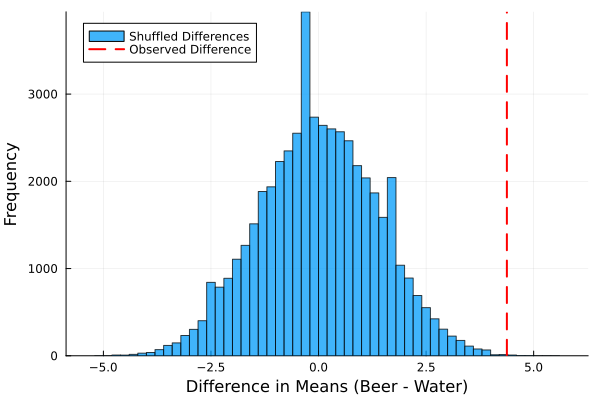

In [13]:
# Plot histogram of simulated differences
histogram(shuffled_difference, bins=50, alpha=0.75, label="Shuffled Differences",
          xlabel="Difference in Means (Beer - Water)", ylabel="Frequency")

# Add observed difference as a vertical dashed line
vline!([observed_difference], linestyle=:dash, linewidth=2, color=:red, label="Observed Difference")

# Show the legend
plot!(legend=:topleft)

In [14]:
p_value = mean(abs.(shuffled_difference) .≥ abs(observed_difference))
@show p_value

p_value = 0.00078


0.00078

### Problem 3

A scientific funding agency receives 200 proposals in response to a
call. The panel is asked to evaluate each proposal on two criteria:
scientific rigor and potential impact (or “newsworthiness”). After
standardizing each of these scores to independently follow a standard
normal distribution ($\text{Normal}(0, 1)$), the two standardized scores
are summed to get the total score for the proposal. Based on these total
scores, the top 10% of the proposals are selected for funding.

A researcher who is studying the relationship between rigor and impact
has used data on the funded proposals to claim high-impact proposals are
necessarily less rigorous, and indeed found a statistically significant
negative correlation between the rigor and impact scores for the funded
proposals. You are more skeptical and believe this effect is an artifact
from the selection process, which would make the claim a bit ironic.

**In this problem**:

-   Create a generative model for the grant-selection procedure under
    the null assumption of no correlation between rigor and impact. You
    can sample rigor and impact scores directly from
    $\text{Normal}(0, 1)$.
-   Using 1,000 simulations, compare the distribution of correlations
    between rigor and impact for the funded proposals to the general
    proposal population.
-   Explain why, when conditioning on selection for funding, there might
    be a negative correlation between rigor and impact even when none
    generally exists.

> **Selection-Distortion Effects**
>
> These **selection-distortion effects** are pretty common in
> observational data, going back to [work by Dawes in the 1970s on the
> lack of predictive ability of admission variables on student
> success](https://www.science.org/doi/abs/10.1126/science.187.4178.721)
> and including [studies claiming to identify a causal fingerprint of
> genes on
> outcomes](https://www.nature.com/articles/s41598-021-89020-x).
>
> This is, of course, just one example of how not thinking carefully
> about data-generating processes can fundamentally contaminate
> statistical analyses, emphasizing that **data do not have meaning
> absent a model for how they were generated**.

Each proposal has two scores:
Rigor: How scientifically sound the proposal is.
Impact: How novel the proposal is. and
These two scores follow a Normal(0,1) distribution
- Simulate n_proposals proposals where rigor and impact are sampled from N(0,1). and compute total scores as the sum of rigor and impact.
- Use the 90th percentile of total_score to get the funding cutoff.
- Before selection, I compute the correlation between rigor and impact in the entire dataset, which is expected to be 0.
After selection, I compute the correlation of the funded ones.
- Repeat 1000 times and store in the array

3. I think selection bias is the reason why there might be a negative correlation between rigor and impact even when non generally exists. Within the funded group, if a proposal is high is rigar, it only needs moderate impact score, and it works the other way around, so in the funded group, higher rigor is associated with lower impact, creating a negative correlation.


In [44]:

# Set Number of proposals and simulations
n_proposals = 200
n_simulations = 1000
#array for correlations
correlations_funded = zeros(n_simulations)
correlations_all = zeros(n_simulations)

# Simulation loop using Normal(0,1)
for i in 1:n_simulations
    rigor = rand(Normal(0,1), n_proposals)
    impact = rand(Normal(0,1), n_proposals)
    # Compute total scores
    total_score = rigor .+ impact
    # Select top 10% for funding
    threshold = percentile(total_score, 90)
    funded_mask = total_score .>= threshold
    # Compute correlations
    correlations_all[i] = cor(rigor, impact)
    correlations_funded[i] = cor(rigor[funded_mask], impact[funded_mask])
end

In [45]:
# Display mean correlations
mean_corr_all = mean(correlations_all)
mean_corr_funded = mean(correlations_funded)
@show mean_corr_all
@show mean_corr_funded

mean_corr_all = 0.00626683743973895
mean_corr_funded = -0.6903070898477384


-0.6903070898477384

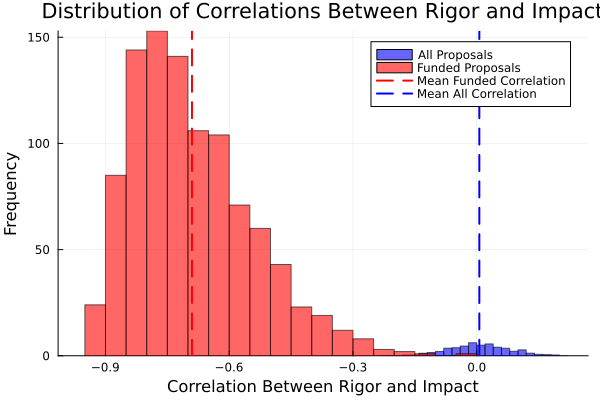

In [46]:
# Plot histograms
histogram(correlations_all, bins=30, alpha=0.6, label="All Proposals", color=:blue,
          xlabel="Correlation Between Rigor and Impact", ylabel="Frequency",
          title="Distribution of Correlations Between Rigor and Impact", normalize=true)
histogram!(correlations_funded, bins=30, alpha=0.6, label="Funded Proposals", color=:red)
vline!([mean(correlations_funded)], linestyle=:dash, linewidth=2, color=:red, label="Mean Funded Correlation")
vline!([mean(correlations_all)], linestyle=:dash, linewidth=2, color=:blue, label="Mean All Correlation")
plot!(legend=:topright)

### Problem 4

You are trying to detect how prevalent cheating was on an exam. You are
skeptical of the efficacy of just asking the students if they cheated.
You are also concerned about privacy — your goal is not to punish
individual students, but to see if there are systemic problems that need
to be addressed. Someone proposes the following interview procedure,
which the class agrees to participate in:

> Each student flips a fair coin, with the results hidden from the
> interviewer. The student answers honestly if the coin comes up heads.
> Otherwise, if the coin comes up tails, the student flips the coin
> again, and answers “I did cheat” if heads, and “I did not cheat”, if
> tails.

We have a hypothesis that cheating was not prevalent, and the proportion
of cheaters was no more than 5% of the class; in other words, we expect
5 “true” cheaters out of a class of 100 students. Our TA is more jaded
and thinks that cheating was more rampant, and that 30% of the class
cheated. The proposed interview procedure is noisy: the interviewer does
not know if an admission means that the student cheated, or the result
of a heads. However, it gives us a data-generating process that we can
model and analyze for consistency with our hypothesis and that of the
TA.

**In this problem**:

-   Derive and code a simulation model for the above interview procedure
    given the “true” probability of cheating $p$.
-   Simulate your model (for a class of 100 students) 50,000 times under
    a null hypothesis of no cheating, your hypothesis of 5% cheating,
    the TA’s hypothesis of 30% cheating, and plot the resulting
    datasets.
-   If you received 31 “Yes, I cheated” responses while interviewing
    your class, what could you conclude?
-   How useful do you think the interview procedure is to identify
    systemic cheating? What changes to the design might you make?

Each student follows this process:

Flip a fair coin:
Heads → Answer truthfully.
Tails → Flip a second coin:
Heads → Answer "I did cheat".
Tails → Answer "I did not cheat".

Students who cheated will answer "Yes, I did cheat" if
1. They get heads on the first flip(50%)
2. They get trails on the first flip, then heads on the second flip = 25%, thus total probability = 75%

Student who did no cheat will answer "Yes, I did cheat" if
1. They get tails on the first flip (50%), then heads on the second flip(25%).

- Expected proportion of "Yes, I did cheat" is 0.75p + 0.25(1-p) = fractions of I did cheat answer

- I will set up 2 model to test out hypothesis, and TA's hypothesis

1. If i received 31 yes responses, I'll conclude that Our hypothesis(5%) is plausible based on the observed data, while TA's hypothesis(30%) are likely overestimates the actual cheating rate.
2. This method does provides a statistical estimate without revealing who is actually cheating, however the noisy response does makes it harder to know the exact cheating number, and requires a relative large sample sizes. I think we can adjust the second coin flip probability, and increase the number of responses in order to reduce noise.

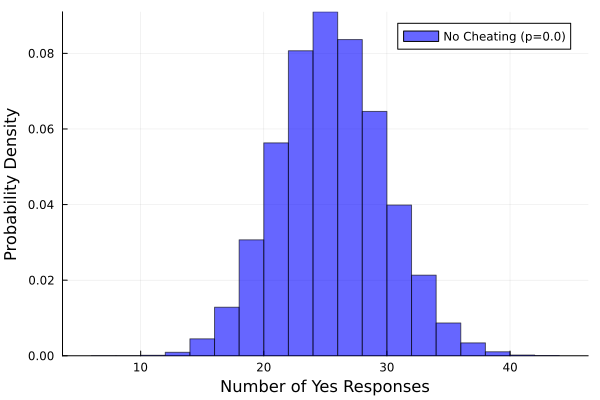

In [60]:
# Set random seed for reproducibility
Random.seed!(50)

# Function to simulate the interview process
function simulate_cheating_response(p_cheat, n_students=100, n_simulations=50000)
    yes_responses = zeros(n_simulations)  # Store "Yes, I cheated" responses

    for i in 1:n_simulations
        # Step 1: Generate true cheaters based on probability p_cheat
        true_cheaters = rand(n_students) .< p_cheat  # Boolean array

        # Step 2: First coin flip (50% chance of truthful answer)
        first_coin_heads = rand(n_students) .< 0.5  

        # Step 3: Second coin flip (for those who got tails first)
        second_coin_heads = rand(n_students) .< 0.5  

        # Step 4: Determine student responses
        responses = first_coin_heads .* true_cheaters .+ .!first_coin_heads .* second_coin_heads  

        yes_responses[i] = sum(responses)  # Count "Yes" responses
    end

    return yes_responses
end
# Number of students and simulations
n_students = 100
n_simulations = 50000

# Simulate for different hypotheses
null_hypothesis = simulate_cheating_response(0.0, n_students, n_simulations)  # No cheating
histogram(null_hypothesis, bins=30, alpha=0.6, label="No Cheating (p=0.0)", color=:blue, normalize=true,
          xlabel="Number of Yes Responses", ylabel="Probability Density")

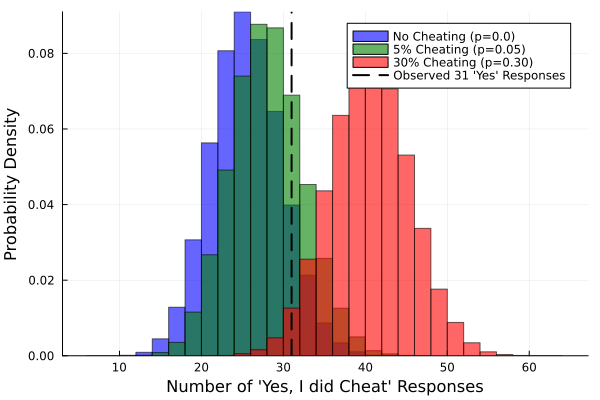

In [62]:
ta_hypothesis = simulate_cheating_response(0.30, n_students, n_simulations)  # 30% cheating
histogram(null_hypothesis, bins=30, alpha=0.6, label="No Cheating (p=0.0)", color=:blue, normalize=true,
          xlabel="Number of 'Yes, I did Cheat' Responses", ylabel="Probability Density")
histogram!(our_hypothesis, bins=30, alpha=0.6, label="5% Cheating (p=0.05)", color=:green, normalize=true)
histogram!(ta_hypothesis, bins=30, alpha=0.6, label="30% Cheating (p=0.30)", color=:red, normalize=true)
vline!([31], linestyle=:dash, linewidth=2, color=:black, label="Observed 31 'Yes' Responses")
plot!(legend=:topright)

### Problem 5

**This problem is only required for students in BEE 5850**.

Adjusting for inflation, there has been an increase in tropical cyclone
damages on the U.S. Atlantic coast between 1900 and 2022 (see
<a href="#fig-tc" class="quarto-xref">Figure 1</a>).

<figure id="fig-tc">
<img src="attachment:figures/normalized-TC-damages.jpg" />
<figcaption>Figure 1: Change in tropical cyclone damages in U.S.
Atlantic coastal counties from 1900–2022, aggregated by pentad and
normalized to 2018 U.S. dollars. The red line shows an exponential trend
of 1.06%/yr growth in damages. Reproduced from <a
href="https://doi.org/10.1175/JAMC-D-24-0047.1">Willoughby, Hernandez,
&amp; Pinnock (2024)</a>.</figcaption>
</figure>

**In this problem**:

-   Describe two different mechanisms by which tropical cyclone damages
    in coastal counties might have increased over this period.
-   How might you propose to examine the relative strengths of these
    mechanisms? You don’t need to actually do this (this is indeed a
    somewhat thorny debate in the literature), but think about potential
    modeling and data approaches.

*REASON*
1. Warmer ocean temperatures provide more energy to tropical cyclones, increasing their intensity.
2. The fast pace urbanization of U.S. coastal areas leads to more homes and infrastructure in hurrican-prone areas, thus increases the damages.
--------------------------------------------------------------------------------
Simulate historical storm data but apply modern population & infrastructure conditions to see how damages would differ. 
Do the same for today's storm in past urbanization. Increase surface temperature and wind speeds but keep past infrastructure. If damages increase significantly, climate-driven intensity is the main factor.

## References

- Question 1 reference.
1. https://www.statista.com/statistics/266292/number-of-pirate-attacks-worldwide-since-2006/
2. https://data.worldbank.org/indicator/SE.PRM.TCAQ.ZS
- Question 5 reference.
1. https://www.epa.gov/climate-indicators/climate-change-indicators-tropical-cyclone-activity
